# NORMALIZACIÓN, SELECCIÓN DE CARACTERÍSTICAS Y REDUCCIÓN DE LA DIMENSIONALIDAD. 
# VALIDACIÓN CRUZADA

## Creacion diferentes conjuntos de datos

### Cargar conjunto de datos
Cargar el conjunto de datos y visualizarlo. Llamaremos a este conjunto de datos conjunto de datos original.

Valor de salida: Dataframe cargado (variable conjunto_de_datos_original)

Gráfico de pares generado:


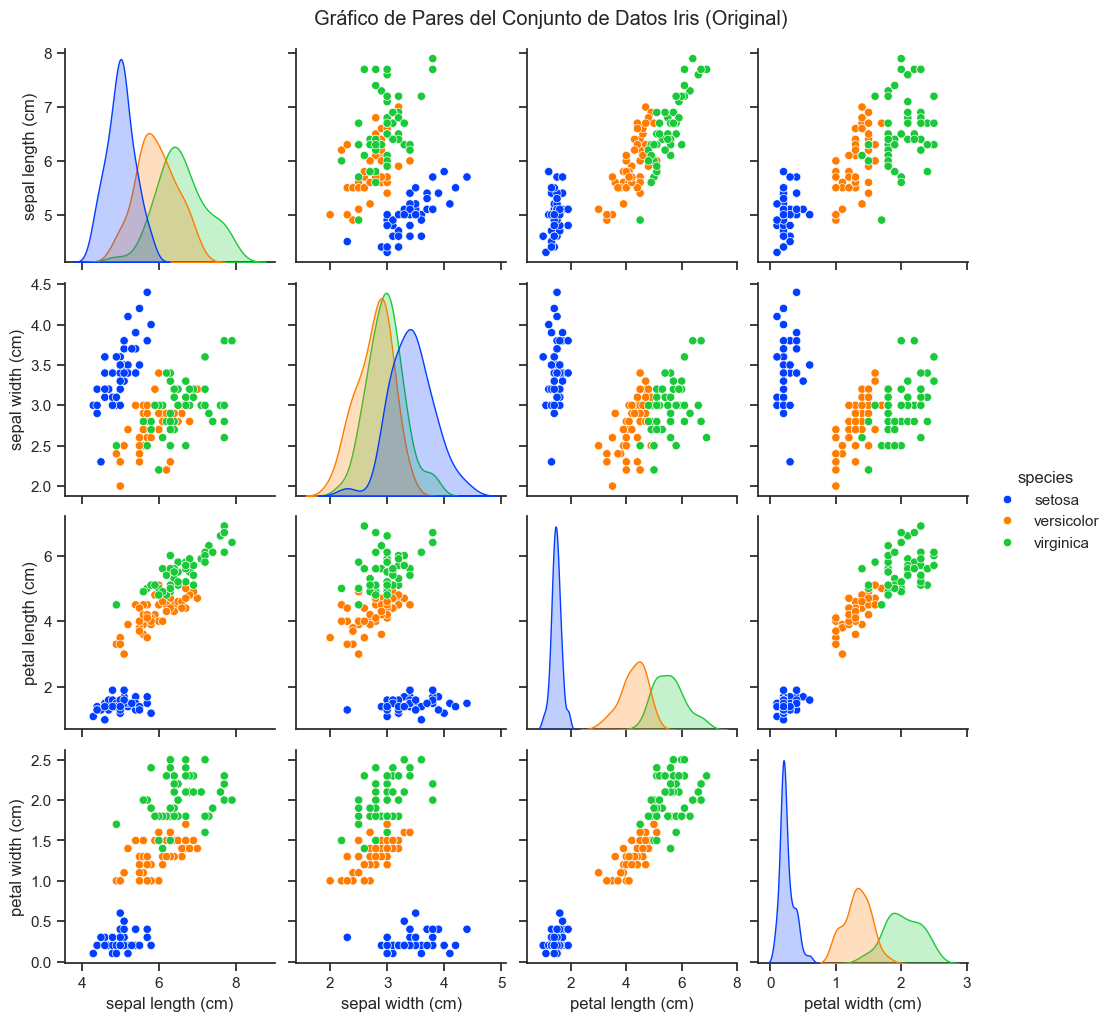

In [5]:
import pandas as pd
from sklearn.datasets import load_iris
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el conjunto de datos original
iris = load_iris()
conjunto_de_datos_original = pd.DataFrame(data=iris.data, columns=iris.feature_names)
conjunto_de_datos_original['target'] = iris.target

# Mapear los targets (0, 1, 2) a los nombres de las especies para una mejor visualización
conjunto_de_datos_original['species'] = conjunto_de_datos_original['target'].map({
    0: iris.target_names[0],
    1: iris.target_names[1],
    2: iris.target_names[2]
})

# Visualizar el conjunto de datos
print("Gráfico de pares generado:")

# Configurar el estilo de Seaborn
sns.set_theme(style="ticks")

# Crear el pairplot, coloreando por la columna 'species'
# Usamos 'vars' para graficar solo las columnas de características (no 'target')
pair_plot = sns.pairplot(
    conjunto_de_datos_original,
    hue='species',  # Colorear puntos por especie
    palette='bright', # Paleta de color
    vars=iris.feature_names # Seleccionar solo las 4 columnas de características
)

# Añadir un título general al gráfico
pair_plot.figure.suptitle("Gráfico de Pares del Conjunto de Datos Iris (Original)", y=1.02)

# Mostrar el gráfico
plt.show()

### Estandarizar el conjunto
Estandarizar el conjunto de datos original a escala unitaria (media = 0 y varianza = 1)
y visualizarlo. Llamaremos a este conjunto de datos conjunto de datos estandarizado.

Entradas: Dataframe original (variable conjunto_de_datos_original)


Salidas: Dataframe estandarizado (variable conjunto_de_datos_estandarizado)

Gráfico de pares (Estandarizado)


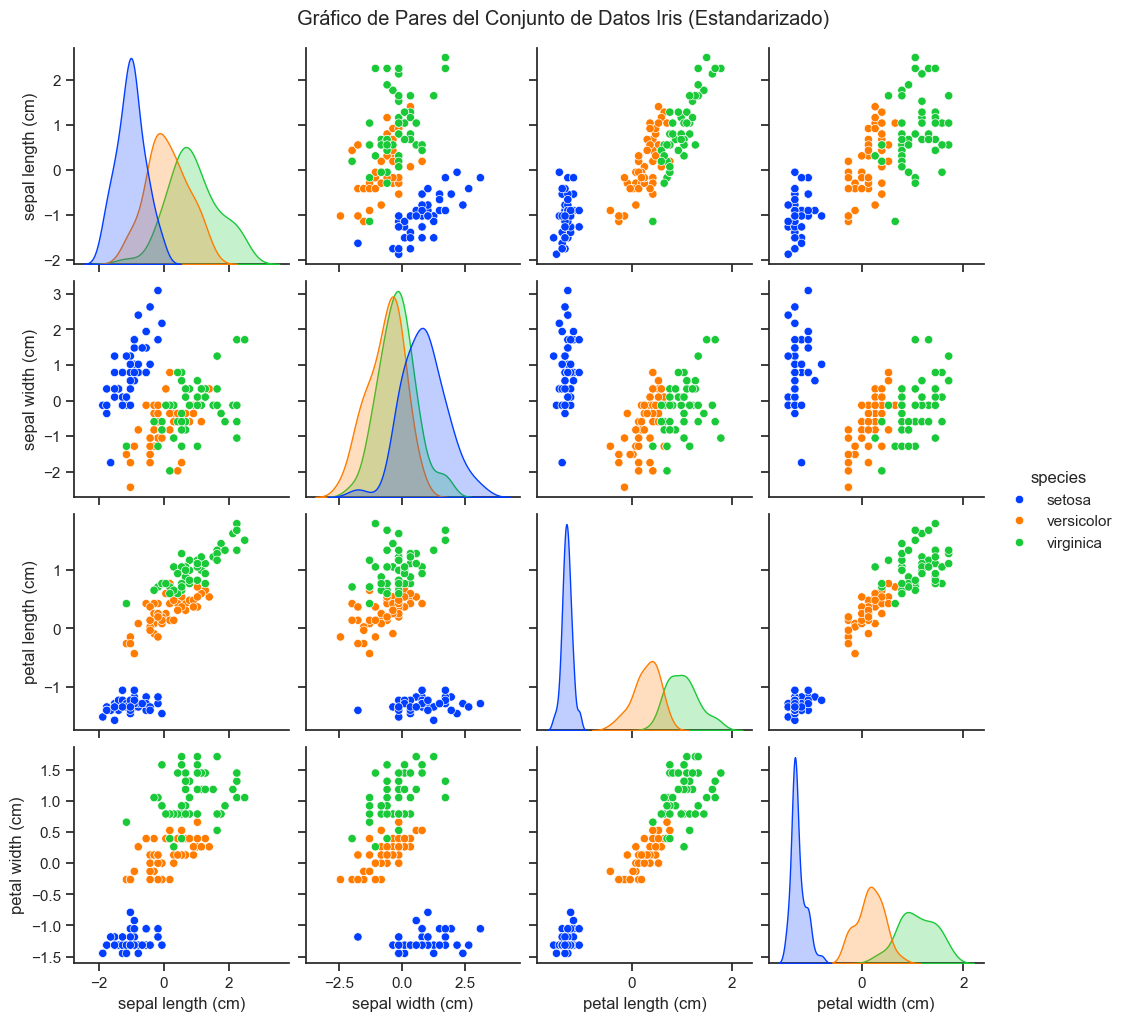

In [6]:
#Primeramente, debemos realizar una selección de características para reducir la dimensionalidad del conjunto de datos.
from sklearn.preprocessing import StandardScaler

# Separamos las características y la variable objetivo
X = conjunto_de_datos_original[iris.feature_names]     # Tomamos solo las columnas de características
y = conjunto_de_datos_original['target']               # Tomamos la columna de la variable objetivo

# Estandarizamos y transformamos las 4 características originales
scaler = StandardScaler()                               
X_scaled = scaler.fit_transform(X)                     # Calcula la media y la desviación estándar

# Reconstruimos el DataFrame con las características estandarizadas
conjunto_de_datos_estandarizados = pd.DataFrame(data=X_scaled, columns=iris.feature_names)

# Añadimos la columna 'species' para poder usarla en la visualización
conjunto_de_datos_estandarizados['species'] = conjunto_de_datos_original['species']

# Visualizamos el conjunto de datos estandarizado
print("Gráfico de pares (Estandarizado)")
sns.set_theme(style="ticks")                    # Configurar el estilo de Seaborn

pair_plot_scaled = sns.pairplot(
    conjunto_de_datos_estandarizados, 
    hue='species',                              # Colorear puntos por especie
    palette='bright',
    vars=iris.feature_names                     # Seleccionar solo las 4 columnas de características
)

pair_plot_scaled.figure.suptitle("Gráfico de Pares del Conjunto de Datos Iris (Estandarizado)", y=1.02)
plt.show()

### Normalizar el conjunto
Normalizar el conjunto de datos original a un rango fijo [0, 1] y visualizarlo. Llamaremos a este conjunto de datos conjunto de datos normalizado.

Entradas: Dataframe original (variable conjunto_de_datos_original)

Salidas: Dataframe normalizado (variable conjunto_de_datos_nomalizado)

Gráfico de pares (Normalizado)


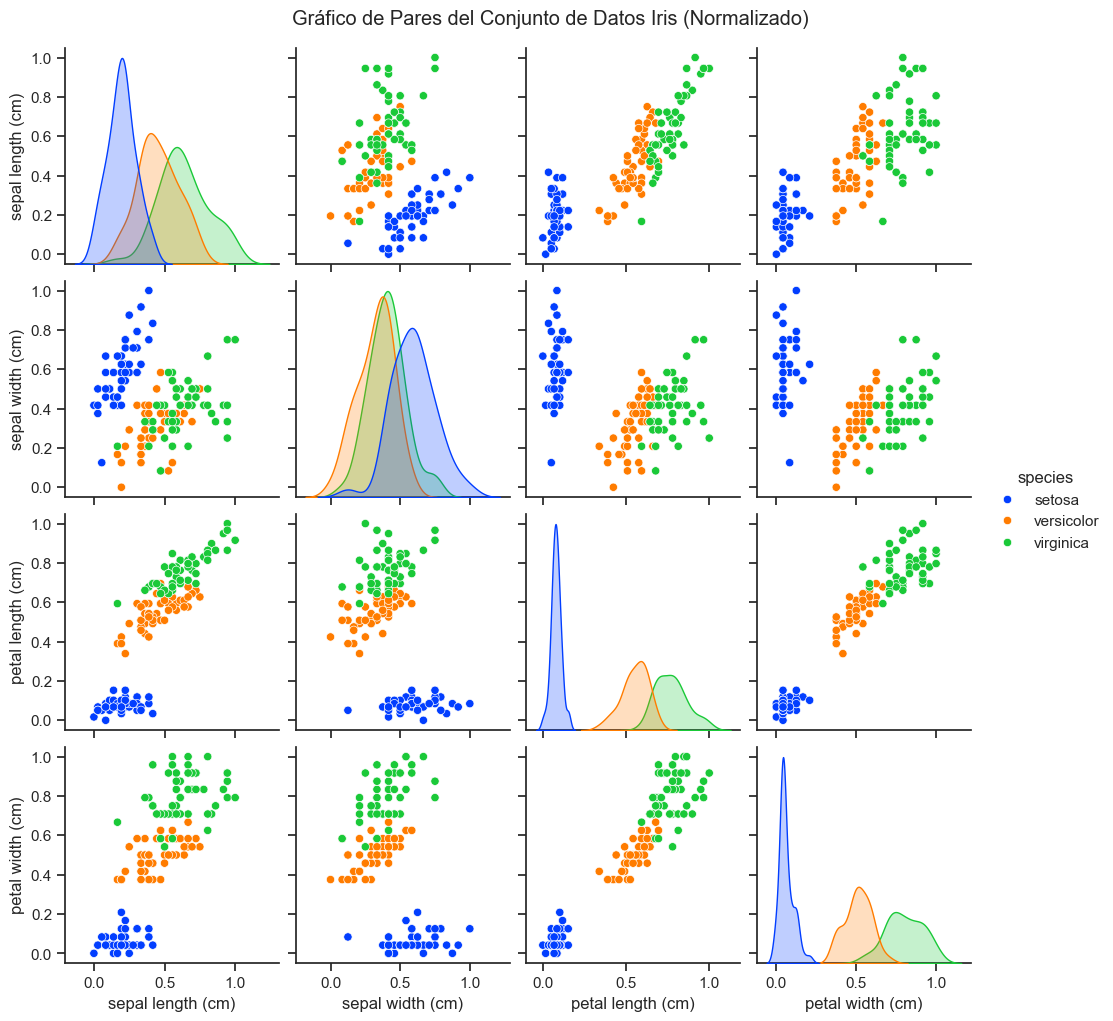

In [7]:
from sklearn.preprocessing import MinMaxScaler
# Ahora aplicamos la normalización Min-Max donde el nuevo mínimo es 0 y el nuevo máximo es 1
min_max_scaler = MinMaxScaler()
X_min_max = min_max_scaler.fit_transform(X)   # Ajusta y transforma los datos, usando los datos originales X de las características

# Reconstruimos el DataFrame con las características normalizadas
conjunto_de_datos_normalizados = pd.DataFrame(data=X_min_max, columns=iris.feature_names) # Establecemos las características como columnas

# Añadimos la columna 'species' para poder usarla en la visualización
conjunto_de_datos_normalizados['species'] = conjunto_de_datos_original['species']

# Visualizamos el conjunto de datos normalizado
print("Gráfico de pares (Normalizado)")
sns.set_theme(style="ticks")                    # Configurar el estilo de Seaborn

pair_plot_min_max = sns.pairplot(
    conjunto_de_datos_normalizados,
    hue='species',                              # Colorear puntos por especie
    palette='bright',
    vars=iris.feature_names                     # Seleccionar solo las 4 columnas de características
)

pair_plot_min_max.figure.suptitle("Gráfico de Pares del Conjunto de Datos Iris (Normalizado)", y=1.02)
plt.show()

### Declarar funcion para PCA
Esto no lo pone en el pdf pero para no repetir codigo todas las celdas, vamos a declarar la siguiente funcion:

Nombre: get_pca

Variables de Entrada:
- df (Dataframe al que realizarle el PCA)
- perc (Porcentaje de PCA a aplicar)

Retorna : df_PCA (Dataframe con el PCA hecho)

In [17]:
from sklearn.decomposition import PCA
import numpy as np  

# Definimos la función para aplicar PCA y reducir a 2 dimensiones
def get_pca(X, conjunto_de_datos, porcentaje_var_explicada):
    pca = PCA(n_components=porcentaje_var_explicada)  # Inicializamos PCA con el porcentaje de varianza explicada deseado
    X_pca = pca.fit_transform(X)                      # Ajustamos y transformamos los datos
    
    num_componentes = pca.n_components_               # Obtenemos el número real de componentes seleccionados
    component_name = [f'Componente {i+1}' for i in range(num_componentes)]  # Nombres de las componentes

    df_pca = pd.DataFrame(data=X_pca, columns=component_name)  # Creamos el DataFrame con las componentes principales
    if 'species' in conjunto_de_datos.columns:
        df_pca['species'] = conjunto_de_datos['species']  # Añadimos la columna 'species' si existe
        df_pca['species'] = df_pca['species'].astype('category')  # Convertimos a tipo categórico
    return df_pca

# Definimos la función para crear el pairplot del conjunto de datos PCA
def create_pairplot_PCA(data, hue_col, percentaje_var_explicada,title):
    sns.set_theme(style="ticks")                    # Configurar el estilo de Seaborn
    pair_plot = sns.pairplot(
        data,
        hue=hue_col,
        palette="colorblind"
    )
    pair_plot.figure.suptitle(title, y=1.02)
    plt.show()

### Aplicar PCA 0.95 a datos originales
Aplicar un PCA de 0.95 al conjunto de datos original y visualizarlo. Llamaremos a
este conjunto de datos conjunto de datos originalPCA95.

Entradas: Dataframe original (variable conjunto_de_datos_original)

Salidas Dataframe Original con PCA 0.95 (variable: conjunto_de_datos_originalPCA95)

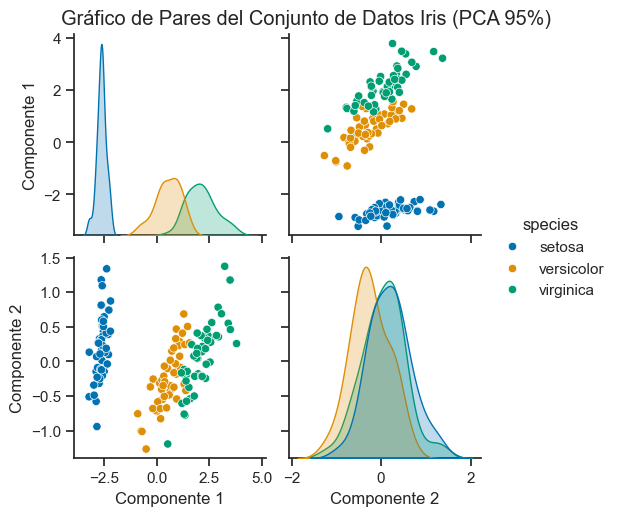

In [9]:
conjunto_de_datos_originalPCA95 = get_pca(X, conjunto_de_datos_original, percentaje_var_explicada=0.95)

create_pairplot_PCA(conjunto_de_datos_originalPCA95
                    ,hue_col="species"
                    ,percentaje_var_explicada=0.95,
                    title="Gráfico de Pares del Conjunto de Datos Iris (PCA 95%)")

### Aplicar PCA 0.80 a datos originales
Aplicar un PCA de 0.80 al conjunto de datos original y visualizarlo. Llamaremos a
este conjunto de datos conjunto de datos originalPCA80.

Entradas: Dataframe original (variable conjunto_de_datos_original)

Salidas Dataframe Original con PCA 0.80 (variable: conjunto_de_datos_originalPCA80)

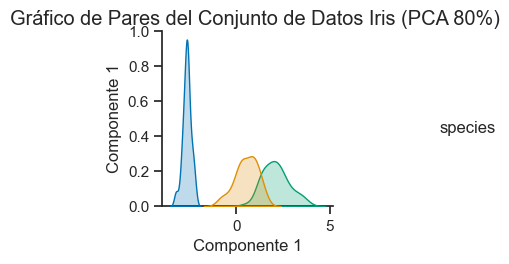

In [10]:
conjunto_de_datos_originalPCA80 = get_pca(X, conjunto_de_datos_original, percentaje_var_explicada=0.80)
create_pairplot_PCA(conjunto_de_datos_originalPCA80
                    ,hue_col="species"
                    ,percentaje_var_explicada=0.80,
                    title="Gráfico de Pares del Conjunto de Datos Iris (PCA 80%)")

### Aplicar PCA 0.95 a datos estandarizados
Aplicar un PCA de 0.95 al conjunto de datos estandarizado y visualizarlo. Llamaremos a
este conjunto de datos conjunto de datos estandarizadoPCA95.

Entradas: Dataframe estandarizado (variable conjunto_de_datos_estandarizado)

Salidas Dataframe estandarizado con PCA 0.95 (variable: conjunto_de_datos_estandarizadoPCA95)

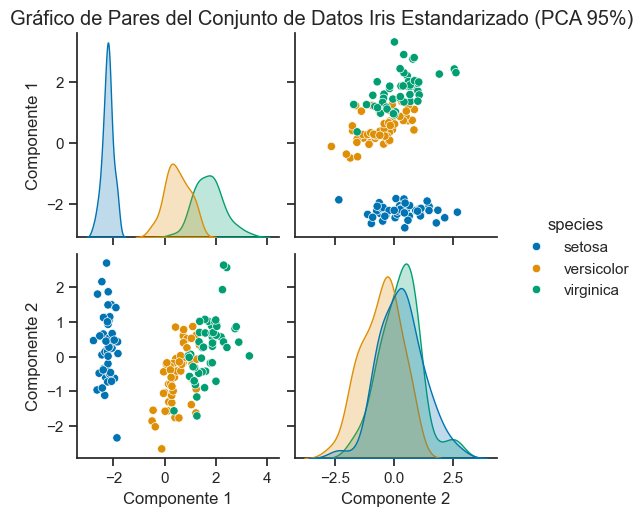

In [11]:
conjunto_de_datos_estandarizadosPCA95 = get_pca(X_scaled, conjunto_de_datos_estandarizados, percentaje_var_explicada=0.95)
create_pairplot_PCA(conjunto_de_datos_estandarizadosPCA95,
                    hue_col="species",
                    percentaje_var_explicada=0.95,
                    title="Gráfico de Pares del Conjunto de Datos Iris Estandarizado (PCA 95%)")

### Aplicar PCA 0.80 a datos estandarizados
Aplicar un PCA de 0.80 al conjunto de datos estandarizado y visualizarlo. Llamaremos a
este conjunto de datos conjunto de datos estandarizadoPCA80.

Entradas: Dataframe estandarizado (variable conjunto_de_datos_estandarizado)

Salidas Dataframe estandarizado con PCA 0.80 (variable: conjunto_de_datos_estandarizadoPCA80)

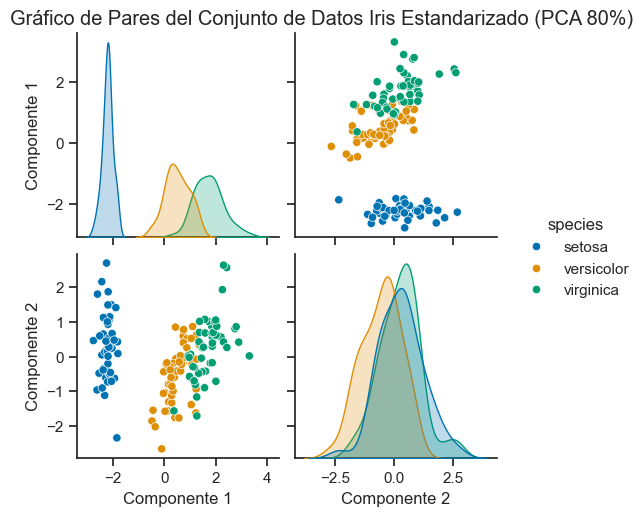

In [12]:
conjunto_de_datos_estandarizadosPCA80 = get_pca(X_scaled, conjunto_de_datos_estandarizados, percentaje_var_explicada=0.80)    
create_pairplot_PCA(conjunto_de_datos_estandarizadosPCA80,
                    hue_col="species",
                    percentaje_var_explicada=0.80,
                    title="Gráfico de Pares del Conjunto de Datos Iris Estandarizado (PCA 80%)")

### Aplicar PCA 0.95 a datos normalizados
Aplicar un PCA de 0.95 al conjunto de datos normalizado y visualizarlo. Llamaremos a
este conjunto de datos conjunto de datos normalizadoPCA95.

Entradas: Dataframe normalizado (variable conjunto_de_datos_normalizado)

Salidas Dataframe normalizado con PCA 0.95 (variable: conjunto_de_datos_normalizadoPCA95)

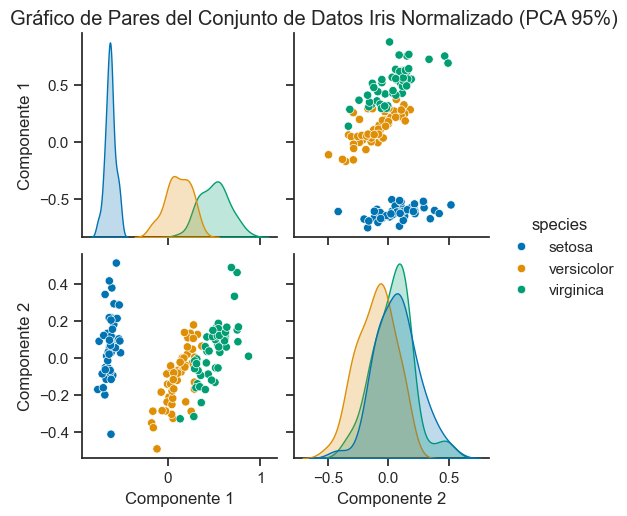

In [13]:
conjunto_de_datos_normalizadosPCA95 = get_pca(X_min_max, conjunto_de_datos_normalizados, percentaje_var_explicada=0.95) 
create_pairplot_PCA(conjunto_de_datos_normalizadosPCA95,
                    hue_col="species",    
                    percentaje_var_explicada=0.95,
                    title="Gráfico de Pares del Conjunto de Datos Iris Normalizado (PCA 95%)")

### Aplicar PCA 0.80 a datos normalizados
Aplicar un PCA de 0.80 al conjunto de datos normalizado y visualizarlo. Llamaremos a
este conjunto de datos conjunto de datos normalizadoPCA80.

Entradas: Dataframe normalizado (variable conjunto_de_datos_normalizado)

Salidas Dataframe normalizado con PCA 0.80 (variable: conjunto_de_datos_normalizadoPCA80)

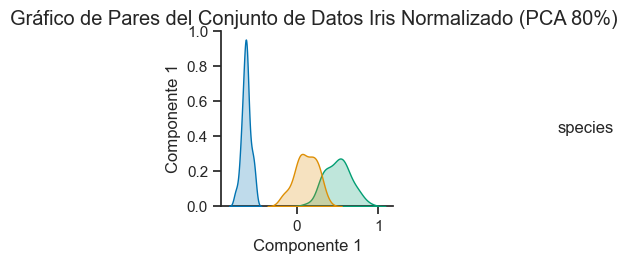

In [14]:
conjunto_de_datos_normalizadosPCA80 = get_pca(X_min_max, conjunto_de_datos_normalizados, percentaje_var_explicada=0.80) 
create_pairplot_PCA(conjunto_de_datos_normalizadosPCA80,  
                    hue_col="species",    
                    percentaje_var_explicada=0.80,
                    title="Gráfico de Pares del Conjunto de Datos Iris Normalizado (PCA 80%)")

## Configurar validación cruzada
Vamos a configurar una validación cruzada de k=5 iteraciones o
pliegues. Esto produce una validación cruzada 80/20, que suele ser la más usada. Este
proceso consiste en lo siguiente:

### Declarar función para K-Folds
Vamos a declarar la siguiente función que nos cree los archivos de kfolds para evitar repetir codigo en cada una de las celdas.

Nombre: get_kfolds
Entradas: 
- k (Número de k folds)
- df (Dataframe para hacerle los kfolds)
- dir (directorio base donde almacenar todos los archivos resultantes)
- subdir (Nombre del subdirectorio donde almacenar las graficas de este caso. EJ: Hacemos kfolds de el conjunto de datos original, pues que sea la carpeta conj_original o similar)
- suffix (Sufijo de cada uno de los archivos cvs generados segun el caso. EJ: cada archivo siempre comienza trainingX siendo X el kfold de la iteracion correspondiente, y seguido a eso hay que poner un nombre identificativo para saber a que dataframe corresponde, un resultado final de ejemplo seria training1_orig (suffix = _orig), validating3_norm_PCA95 (suffix = _norm_PCA95))

Salida:
- Debe generar en la carpeta dir, ordenado en carpetas subdir, archivos en formato .csv con el nombre correspondiente, training3_norm_PCA95, seleccionado con suffix.

El PDF describe el proceso de creación de los K-folds así:

- Dividir el conjunto de datos en k partes, de forma que la primera parte tendrá las n/k primeras muestras del conjunto de datos, la segunda parte tendrá las muestras de la número (n/k)+1 hasta la 2*(n/k), y así hasta la parte k. Es decir, si, por ejemplo, tu conjunto de datos tiene 50 muestras (n=50) y vas a hacer una validación cruzada de 5 pliegues (k=5), tras la partición tendrás 5 partes, donde la primera parte tendrá las 50/5=10 primeras muestras, la segunda parte tendrá las muestras de la número (50/10)+1=11 hasta la 2*(50/5)=20, y así hasta la quinta parte, que tendrá las muestras de la número 41 hasta la 50. Cada parte debe tener el mismo número de elementos por clase.
- Ahora se genera el conjunto de datos de entrenamiento y test correspondiente a la
primera iteración. Para ello, junta las muestras de las partes 2 a k, y esto formará tu
conjunto de entrenamiento, que estará en un archivo "training1" (y estará formado por
(k-1)*(n/k) muestras), mientras que las muestras de la parte 1 formarán tu conjunto
de test (y estará formado por n/k muestras), que estarán en un archivo "test1". Guarda
ambos archivos
- ...Hacer lo mismo hasta la iteración k.

### Generar función Kfolds

In [ ]:
from sklearn.model_selection import KFold
import pandas as pd
import numpy as np
import os

def get_kfolds(k: int, df: pd.DataFrame, dir: str, subdir: str, suffix: str):
    output = os.path.join(dir, subdir)
    os.makedirs(output, exist_ok=True)

    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    
    df_reset = df.reset_index(drop=True) # Reiniciamos indices para la división secuencial

    fold = 1
    for train_index, test_index in kf.split(df_reset):
        df_train = df_reset.iloc[train_index]
        df_test = df_reset.iloc[test_index]

        # Guardar los conjuntos en .csv
        train_path = os.path.join(output, f"training{fold}{suffix}.csv") 
        validating_path = os.path.join(output, f"validating{fold}{suffix}.csv")

        df_train.to_csv(train_path, index=False)
        df_test.to_csv(validating_path, index=False)

        print(f"Fold {fold}: Training={len(df_train)}, Validating={len(df_test)}")
        fold += 1

### Generar KFolds para datos originales

### Generar Kfolds para datos originales con PCA 95

### Generar Kfolds para datos originales con PCA 80

### Generar Kfolds para datos normalizados

### Generar Kfolds para datos normalizados con PCA 95

### Generar Kfolds para datos normalizados con PCA 80

### Generar Kfolds para datos estandarizados

### Generar Kfolds para datos estandarizados con PCA 95

### Generar Kfolds para datos estandarizados con PCA 80